# 02 - holimo_water_ice_variable_comparison\n
Derived from `notebooks/prior_versions/plume_path_plot_clean.ipynb`.\n

In [1]:
import os, platform, socket

def is_server() -> bool:
    # strong signals
    if os.getenv("JUPYTERHUB_API_URL") or os.getenv("JUPYTERHUB_USER"):
        return True
    if os.getenv("SLURM_JOB_ID"):
        return True

    # fallback heuristic (common: local macOS, server Linux)
    return platform.system() != "Darwin"

print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: 22182-mbp-2.tropos.de
is_server: False


In [2]:
from __future__ import annotations

import re, sys
from pathlib import Path
import colormaps as pcmaps
import matplotlib.axes as maxes
import matplotlib.dates as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator, LogLocator, FuncFormatter



xr.set_options(keep_attrs=True)

sys.path.insert(0, str((Path.cwd() / ".." / "src").resolve()))
from utilities import make_pastel, load_plume_path_runs
from utilities.holimo_helpers import load_and_prepare_holimo

def create_new_jet3(n_colors=256, n_ice_colors=32):
    ice_colors = pcmaps.ice(np.linspace(1, 0.5, n_ice_colors))
    bk_colors  = pcmaps.BkBlAqGrYeOrReViWh200(np.linspace(0.1, 0.9, n_colors))
    transition = np.linspace(ice_colors[-1], bk_colors[0], 16)[1:-1]
    return ListedColormap(np.vstack([ice_colors, transition, bk_colors]))

new_jet4 = create_new_jet3(1024)

new_jet3 = create_new_jet3()
new_jet3_soft = make_pastel(new_jet3, desaturation=0.25, darken=0.90)


In [6]:

holimo_file      = '../../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc'

time_window_holimo = (np.datetime64('2023-01-25T10:10:00'), np.datetime64('2023-01-25T12:00:00'))
time_frames_plume = [   
                    [ np.datetime64('2023-01-25T10:55:00'), np.datetime64('2023-01-25T11:10:00')   ],
                    [ np.datetime64('2023-01-25T10:35:00'), np.datetime64('2023-01-25T10:50:00')   ],
                    [ np.datetime64('2023-01-25T11:24:00'), np.datetime64('2023-01-25T11:39:00')   ],
                    ]

obs_ids = [
    "SM059", 
    "SM058", 
    "SM060"
    ]
growth_times_min = [
    6.1, 
    8.0, 
    9.1,
    ]
seeding_start_times = [
    np.datetime64('2023-01-25T10:50:00'),
    np.datetime64('2023-01-25T10:28:00'),
    np.datetime64('2023-01-25T11:15:00'),
]




ds_holimo, lbb, cbb = load_and_prepare_holimo(holimo_file)
ds_holimo = ds_holimo.sel(time=slice(*time_window_holimo))
ds_holimo = ds_holimo.assign_coords({'diameter': ds_holimo.diameter * 1e6})
ds_hd10   = ds_holimo.resample(time='10s').mean()


# Optional HOLIMO overlay: requires ds_hd10, obs_ids, time_frames_plume, growth_times_min.
holimo_ice_var = "Ice_Pristine_PSDnoNorm"
holimo_overlay_cfg = None
if all(name in globals() for name in ["ds_hd10", "obs_ids", "time_frames_plume", "growth_times_min"]):
    holimo_overlay_cfg = {
        "ds_hd10": ds_hd10,
        "obs_ids": obs_ids,
        "time_frames_plume": time_frames_plume,
        "growth_times_min": growth_times_min,
        "seeding_start_times": seeding_start_times,
        "var": holimo_ice_var,
        "threshold": 1e-10,
        "unit_factor": 1e3,
        "scatter_cmap": new_jet3,
        "line_alpha": 0.9,
        "line_width": 2.35,
        "marker_edgecolor": "black",
        "marker_edgewidth": 0.35,
        "marker_size": 7,
        "legend_loc": "upper right",
    }

In [7]:
from pathlib import Path
Path("output").mkdir(parents=True, exist_ok=True)

['Ice_PSDnoNorm', 'Ice_PSDMnoNormMajsiz', 'Ice_PSDlinNorm', 'Ice_PSDlinNormMajsiz', 'Ice_PSDlogNorm', 'Ice_PSDlogNormMajsiz', 'Ice_Pristine_PSDnoNorm', 'Ice_Pristine_PSDMnoNormMajsiz', 'Ice_Pristine_PSDlinNorm', 'Ice_Pristine_PSDlinNormMajsiz', 'Ice_Pristine_PSDlogNorm', 'Ice_Pristine_PSDlogNormMajsiz', 'Ice_Aggregate_PSDnoNorm', 'Ice_Aggregate_PSDMnoNormMajsiz', 'Ice_Aggregate_PSDlinNorm', 'Ice_Aggregate_PSDlinNormMajsiz', 'Ice_Aggregate_PSDlogNorm', 'Ice_Aggregate_PSDlogNormMajsiz', 'Water_PSDnoNorm', 'Water_PSDMnoNormMajsiz', 'Water_PSDlinNorm', 'Water_PSDlinNormMajsiz', 'Water_PSDlogNorm', 'Water_PSDlogNormMajsiz']


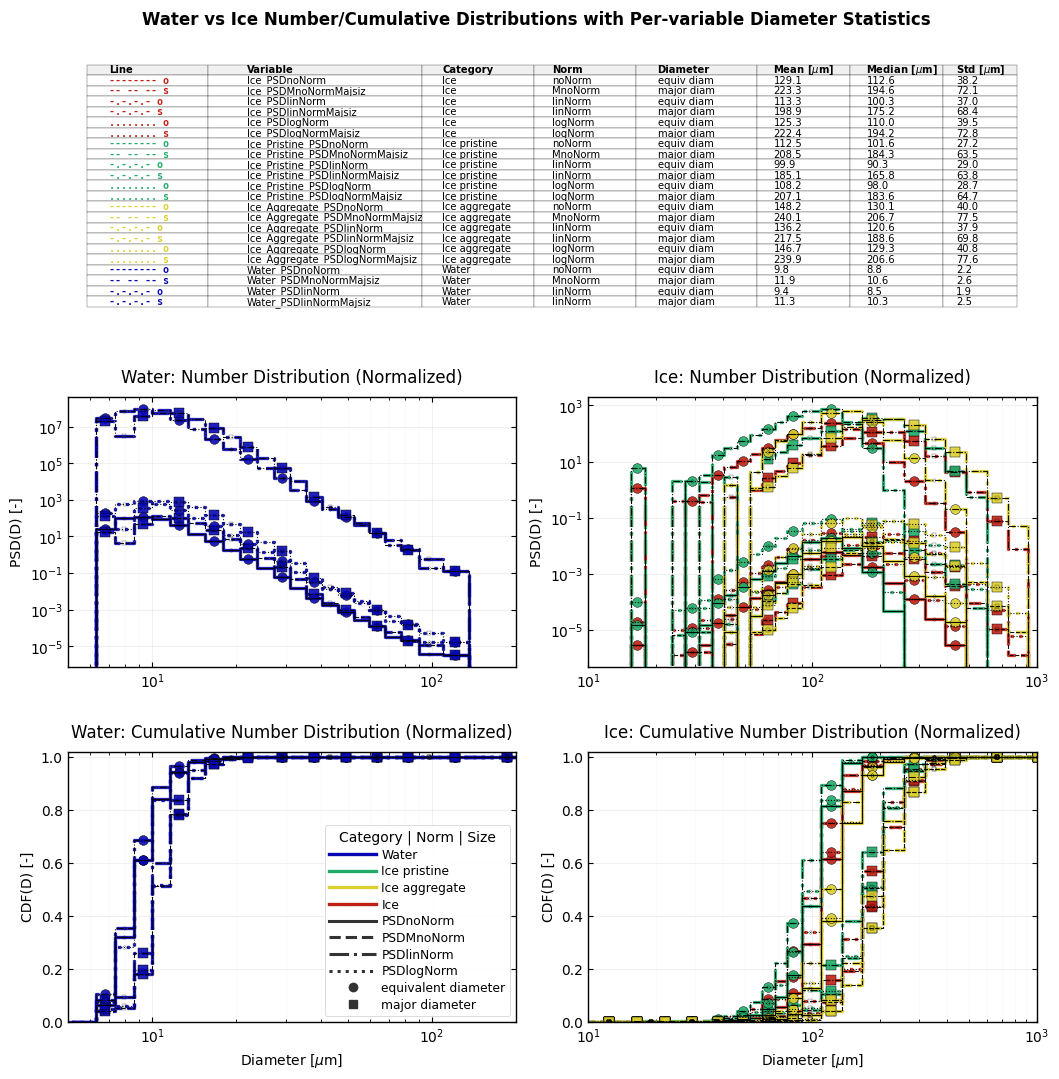

In [ ]:
from matplotlib.lines import Line2D

phase_prefixes = ['Ice_', 'Ice_Pristine_', 'Ice_Aggregate_', 'Water_']
norm_keys = ['PSDnoNorm', 'PSDMnoNorm', 'PSDlinNorm', 'PSDlogNorm']
size_keys = ['', 'Majsiz']

valid_names = [
    f'{prefix}{norm}{size}'
    for prefix in phase_prefixes
    for norm in norm_keys
    for size in size_keys
    if f'{prefix}{norm}{size}' in ds_holimo.data_vars
]
valid_combos = [(norm, size) for norm in norm_keys for size in size_keys]
ds_hd10_frames = [ds_hd10[valid_names].sel(time=slice(t_lo, t_hi)) for t_lo, t_hi in time_frames_plume]


def _diam_stats(d, w):
    valid = np.isfinite(d) & np.isfinite(w) & (w > 0)
    if not valid.any():
        return np.nan, np.nan, np.nan
    d_v, w_v = d[valid], w[valid]
    w_sum = w_v.sum()
    mean_v = np.sum(w_v * d_v) / w_sum
    std_v = np.sqrt(np.sum(w_v * (d_v - mean_v) ** 2) / w_sum)
    median_v = np.interp(0.5, np.cumsum(w_v) / w_sum, d_v)
    return mean_v, median_v, std_v


def _plot_pair(
    ax,
    x,
    y,
    color,
    line_style,
    marker_style,
    line_width=1.6,
    marker_size=4.8,
    line_alpha=0.8,
    marker_edgecolor='black',
    marker_edgewidth=0.9,
    marker_every=2,
):
    ax.step(
        x,
        y,
        color=color,
        linestyle=line_style,
        where='mid',
        marker=marker_style,
        markevery=marker_every,
        ms=marker_size,
        lw=line_width,
        alpha=line_alpha,
        markerfacecolor=color,
        markeredgecolor=marker_edgecolor,
        markeredgewidth=marker_edgewidth,
        zorder=2,
    )
    ax.step(
        x,
        y,
        color='black',
        linestyle=line_style,
        where='mid',
        marker=marker_style,
        markevery=max(1, marker_every + 1),
        ms=marker_size / 3,
        lw=line_width / 3,
        alpha=0.95,
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=max(0.2, marker_edgewidth / 2),
        zorder=3,
    )


fig = plt.figure(figsize=(12.5, 12.5))
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[2.8, 3.0, 3.0], hspace=0.32, wspace=0.16)
ax_tbl = fig.add_subplot(gs[0, :])
ax00, ax01 = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
ax10, ax11 = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])

base_cmap = globals().get('new_jet3_soft', plt.cm.viridis)
category_map = [
    ('Water_', 'Water'),
    ('Ice_Pristine_', 'Ice pristine'),
    ('Ice_Aggregate_', 'Ice aggregate'),
    ('Ice_', 'Ice'),
]
norm_styles = {'PSDnoNorm': '-', 'PSDMnoNorm': '--', 'PSDlinNorm': '-.', 'PSDlogNorm': ':'}
size_markers = {'': 'o', 'Majsiz': 's'}
size_labels = {'': 'equiv diam', 'Majsiz': 'major diam'}
style_tokens = {'-': '--------', '--': '-- -- --', '-.': '-.-.-.-', ':': '........'}

category_order = [label for _, label in category_map]
category_colors = {label: base_cmap(pos) for label, pos in zip(category_order, np.linspace(0.18, 0.82, len(category_order)))}

rows = []
plot_vars = [var for var in valid_names if var in ds_holimo.data_vars]
print(plot_vars)
for var in plot_vars:
    category = next((label for prefix, label in category_map if var.startswith(prefix)), None)
    norm_key = next((key for key in norm_styles if key in var), None)
    size_key = 'Majsiz' if var.endswith('Majsiz') else ''
    if category is None or norm_key is None:
        continue

    dist = ds_holimo[var].mean('time')
    cdf = dist.cumsum('diameter') / dist.sum('diameter')
    mean_v, median_v, std_v = _diam_stats(dist.diameter.values, np.asarray(dist.values, dtype=float))
    ls, mk = norm_styles[norm_key], size_markers[size_key]
    rows.append([
        f"{style_tokens[ls]} {mk}",
        var,
        category,
        norm_key.replace('PSD', ''),
        size_labels[size_key],
        f'{mean_v:.1f}',
        f'{median_v:.1f}',
        f'{std_v:.1f}',
    ])

    ax_psd, ax_cdf = (ax00, ax10) if category == 'Water' else (ax01, ax11)

    important_plot_kwargs = {
        'line_style': ls,
        'marker_style': mk,
        'line_width': holimo_overlay_cfg.get('line_width', 2.0),
        'line_alpha': holimo_overlay_cfg.get('line_alpha', 0.8),
        'marker_size': holimo_overlay_cfg.get('marker_size', 6.5),
        'marker_edgecolor': holimo_overlay_cfg.get('marker_edgecolor', 'black'),
        'marker_edgewidth': holimo_overlay_cfg.get('marker_edgewidth', 0.35),
    }
    _plot_pair(ax_psd, dist.diameter, dist, category_colors[category], **important_plot_kwargs)
    _plot_pair(ax_cdf, dist.diameter, cdf, category_colors[category], **important_plot_kwargs)


ax_tbl.axis('off')
show_rows = rows[:22]
col_labels = ['Line', 'Variable', 'Category', 'Norm', 'Diameter', 'Mean [$\mu$m]', 'Median [$\mu$m]', 'Std [$\mu$m]']
tbl = ax_tbl.table(
    cellText=show_rows,
    colLabels=col_labels,
    loc='center',
    cellLoc='left',
    colLoc='left',
    colWidths=[0.13, 0.23, 0.12, 0.11, 0.13, 0.10, 0.10, 0.08],
    bbox=[0.02, 0.02, 0.96, 0.96],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.2)
tbl.scale(1.12, 1.85)
for (r, c), cell in tbl.get_celld().items():
    cell.set_linewidth(0.2)
    cell.PAD = 0.18
    cell.set_height(cell.get_height() * 1.3)
    if r == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor((0.94, 0.94, 0.94, 1.0))
    elif c == 0:
        cell.set_text_props(color=category_colors[show_rows[r - 1][2]], fontfamily='monospace', weight='bold')

cat_h = [Line2D([0], [0], color=category_colors[label], lw=2.4, label=label) for label in category_order]
norm_h = [Line2D([0], [0], color='0.2', lw=2.2, linestyle=style, label=key) for key, style in norm_styles.items()]
size_h = [
    Line2D([0], [0], color='0.2', lw=0, marker=marker, ms=6, label=('major diameter' if key == 'Majsiz' else 'equivalent diameter'))
    for key, marker in size_markers.items()
]
leg = ax10.legend(
    handles=cat_h + norm_h + size_h,
    labels=[h.get_label() for h in cat_h + norm_h + size_h],
    title='Category | Norm | Size',
    loc='lower right',
    frameon=True,
    framealpha=0.95,
    fontsize=8.8,
    title_fontsize=10,
    ncol=1,
    handlelength=3.8,
    handletextpad=0.45,
    borderpad=0.38,
    labelspacing=0.3,
)
leg.get_frame().set_linewidth(0.5)

for ax in (ax00, ax01):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('PSD(D) [-]')
    ax.grid(which='major', alpha=0.18, lw=0.8)
    ax.grid(which='minor', alpha=0.08, lw=0.5)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

for ax in (ax10, ax11):
    ax.set_xscale('log')
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('Diameter [$\mu$m]')
    ax.set_ylabel('CDF(D) [-]')
    ax.grid(which='major', alpha=0.18, lw=0.8)
    ax.grid(which='minor', alpha=0.08, lw=0.5)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax00.set_xlim(5e0, 2e2)
ax10.set_xlim(5e0, 2e2)
ax01.set_xlim(1e1, 1e3)
ax11.set_xlim(1e1, 1e3)
ax00.set_title('Water: Number Distribution (Normalized)', pad=10)
ax01.set_title('Ice: Number Distribution (Normalized)', pad=10)
ax10.set_title('Water: Cumulative Number Distribution (Normalized)', pad=10)
ax11.set_title('Ice: Cumulative Number Distribution (Normalized)', pad=10)
for ax in (ax00, ax01, ax10, ax11):
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

fig.suptitle('Water vs Ice Number/Cumulative Distributions with Per-variable Diameter Statistics', y=0.92, fontsize=12, fontweight='semibold')
fig.savefig('output/figure12_holimo_water_ice_variable_comparison.png', dpi=300, bbox_inches='tight')

## Figure caption

**Figure 12.** HOLIMO water-versus-ice variable comparison highlighting differences in characteristic particle size and distribution amplitude across the available PSD definitions. The top row shows normalized particle size distributions (PSD), and the bottom row shows the corresponding cumulative distributions (CDF). Left panels summarize water variables and right panels summarize ice variables, enabling direct comparison of modal diameter, spectral width, and relative magnitude between variable formulations.